### Pacotes importados

In [ ]:
# codigo aqui

## Chapter 10: Newton's local method

### Algorithm 10.1: Newton's local method

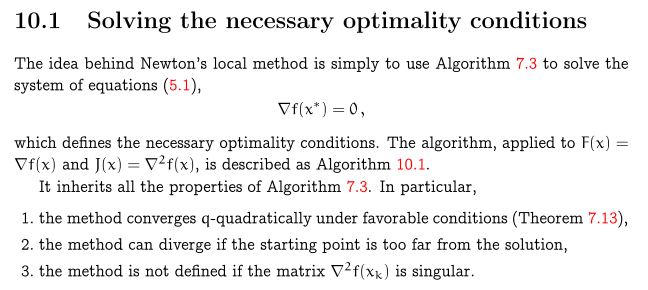

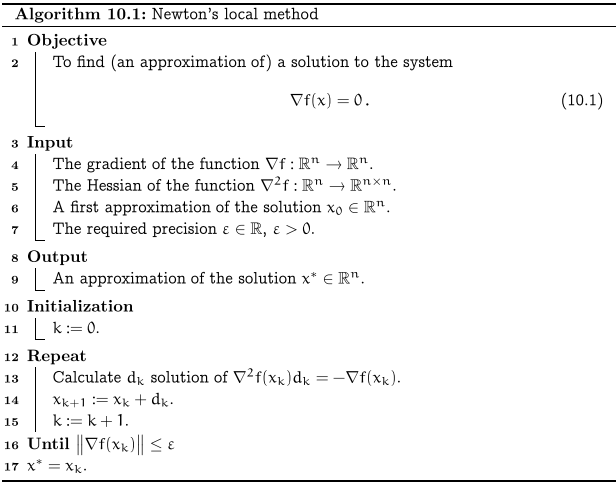

Example 5.8: $f(x_1,x_2) = \frac{1}{2} x_1^2 + x_1 \cos(x_2)$; $x_0 = [1.0, 1.0]$

Método de Newton local
Ponto inicial: [1.0, 1.0]
Iteração |      x1       |      x2       |   ||grad||   |    f(x)
       0 |    1.00000000 |    1.00000000 |  1.75517e+00 |  1.04030e+00
       1 |   -0.23384513 |    1.36419221 |  2.30665e-01 | -2.06286e-02
       2 |    0.01081438 |    1.58483641 |  1.12841e-02 | -9.33544e-05
       3 |   -0.00000213 |    1.57079327 |  2.32350e-06 | -4.24133e-12
       4 |    0.00000000 |    1.57079633 |  8.35431e-17 |  1.41692e-33

Convergência atingida.
Resultado final
x* = [1.990485074400243e-17, 1.5707963267948966]
f(x*) = 1.4169221291279266e-33
grad f(x*) = [8.113719070137009e-17, -1.990485074400243e-17]
||grad f(x*)|| = 8.354308348422095e-17

Classificação do ponto:
Hessiana:
[1.0 -1.0; -1.0 -1.2188205875574195e-33]
Determinante da Hessiana = -1.0
Autovalores da Hessiana = [-0.6180339887498948, 1.618033988749895]
Conclusão: ponto de sela.

Valor esperado teoricamente:
x* ≈ [0, π/2] = [0.0, 1.5707963267948966]
Teste com vários pontos iniciais

Pon

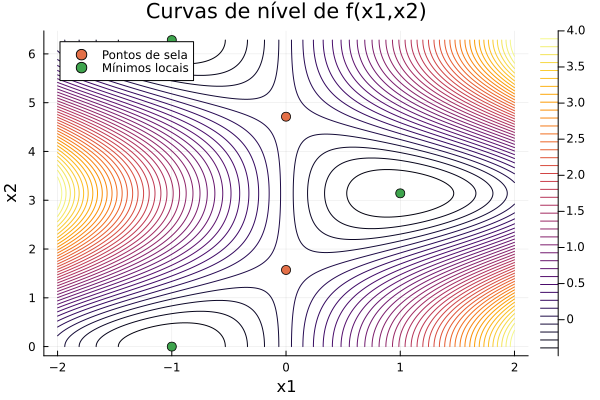

In [6]:
using LinearAlgebra
using Printf
using Plots
# Função objetivo
# f(x1,x2) = 1/2*x1^2 + x1*cos(x2)

function f(x)
    x1 = x[1]
    x2 = x[2]
    return 0.5*x1^2 + x1*cos(x2)
end

# Gradiente da função
#
# df/dx1 = x1 + cos(x2)
# df/dx2 = -x1*sin(x2)

function grad_f(x)
    x1 = x[1]
    x2 = x[2]

    return [
        x1 + cos(x2);
        -x1*sin(x2)
    ]
end

# Hessiana da função
#
# H = [ 1              -sin(x2)
#      -sin(x2)       -x1*cos(x2) ]


function hess_f(x)
    x1 = x[1]
    x2 = x[2]

    return [
        1.0        -sin(x2);
       -sin(x2)   -x1*cos(x2)
    ]
end


# Classificação do ponto estacionário

function classificar_ponto(x)
    H = hess_f(x)
    detH = det(H)
    autovalores = eigvals(H)

    println("\nClassificação do ponto:")
    println("Hessiana:")
    println(H)
    println("Determinante da Hessiana = ", detH)
    println("Autovalores da Hessiana = ", autovalores)

    if all(autovalores .> 0)
        println("Conclusão: mínimo local.")
    elseif all(autovalores .< 0)
        println("Conclusão: máximo local.")
    elseif any(autovalores .> 0) && any(autovalores .< 0)
        println("Conclusão: ponto de sela.")
    else
        println("Conclusão: teste inconclusivo.")
    end
end

# Método de Newton local
#
# Resolve:
# H(xk) * dk = -grad_f(xk)
#
# Depois:
# x(k+1) = xk + dk

function newton_local(x0; ε=1e-8, max_iter=50, mostrar=true)
    x = copy(x0)

    if mostrar
        println("Método de Newton local")
        println("Ponto inicial: ", x0)
        println("Iteração |      x1       |      x2       |   ||grad||   |    f(x)")
    
    end

    for k in 0:max_iter
        g = grad_f(x)
        H = hess_f(x)
        norma_grad = norm(g)

        if mostrar
            @printf("%8d | %13.8f | %13.8f | %12.5e | %12.5e\n",
                    k, x[1], x[2], norma_grad, f(x))
        end

        if norma_grad <= ε
            if mostrar
                println("\nConvergência atingida.")
            end
            return x
        end

        if abs(det(H)) < 1e-12
            error("Hessiana singular ou quase singular. O método de Newton não está definido neste ponto.")
        end

        d = H \ (-g)

        x = x + d
    end

    println("\nNúmero máximo de iterações atingido.")
    return x
end

x0 = [1.0, 1.0]

x_sol = newton_local(x0)

println("Resultado final")
println("x* = ", x_sol)
println("f(x*) = ", f(x_sol))
println("grad f(x*) = ", grad_f(x_sol))
println("||grad f(x*)|| = ", norm(grad_f(x_sol)))

classificar_ponto(x_sol)

println("\nValor esperado teoricamente:")
println("x* ≈ [0, π/2] = ", [0.0, π/2])

pontos_iniciais = [
    [1.0, 1.0],
    [-1.0, 0.5],
    [2.0, 3.0],
    [-2.0, 3.0],
    [1.0, 4.0],
    [-1.0, 6.0],
    [0.5, 5.0],
    [-0.5, 2.0]
]

println("Teste com vários pontos iniciais")

for x0_teste in pontos_iniciais
    try
        x_resultado = newton_local(x0_teste, mostrar=false)

        println("\nPonto inicial: ", x0_teste)
        println("Solução encontrada: ", x_resultado)
        println("f(x*) = ", f(x_resultado))
        println("grad f(x*) = ", grad_f(x_resultado))
        println("||grad|| = ", norm(grad_f(x_resultado)))
        println("det(H) = ", det(hess_f(x_resultado)))

        autovalores = eigvals(hess_f(x_resultado))

        if all(autovalores .> 0)
            println("Tipo: mínimo local")
        elseif all(autovalores .< 0)
            println("Tipo: máximo local")
        elseif any(autovalores .> 0) && any(autovalores .< 0)
            println("Tipo: ponto de sela")
        else
            println("Tipo: inconclusivo")
        end

    catch e
        println("\nPonto inicial: ", x0_teste)
        println("Erro: ", e)
    end
end

println("Algumas soluções estacionárias analíticas")

println("1) Pontos de sela:")
println("(0, π/2), (0, 3π/2), (0, 5π/2), ...")

println("\n2) Mínimos locais:")
println("(-1, 0), (1, π), (-1, 2π), (1, 3π), ...")

println("\nObservação:")
println("O método de Newton local resolve grad f(x) = 0.")
println("Portanto, ele pode encontrar mínimos locais, mas também pode encontrar pontos de sela.")

x1_vals = range(-2, 2, length=200)
x2_vals = range(0, 2π, length=200)

Z = [f([x1, x2]) for x2 in x2_vals, x1 in x1_vals]

contour(
    x1_vals,
    x2_vals,
    Z,
    levels=40,
    xlabel="x1",
    ylabel="x2",
    title="Curvas de nível de f(x1,x2)",
    label=false
)

scatter!(
    [0.0, 0.0],
    [π/2, 3π/2],
    label="Pontos de sela",
    markersize=5
)
scatter!(
    [-1.0, 1.0, -1.0],
    [0.0, π, 2π],
    label="Mínimos locais",
    markersize=5
)

### Algorithm 10.2: Newton's local method by quadratic modeling

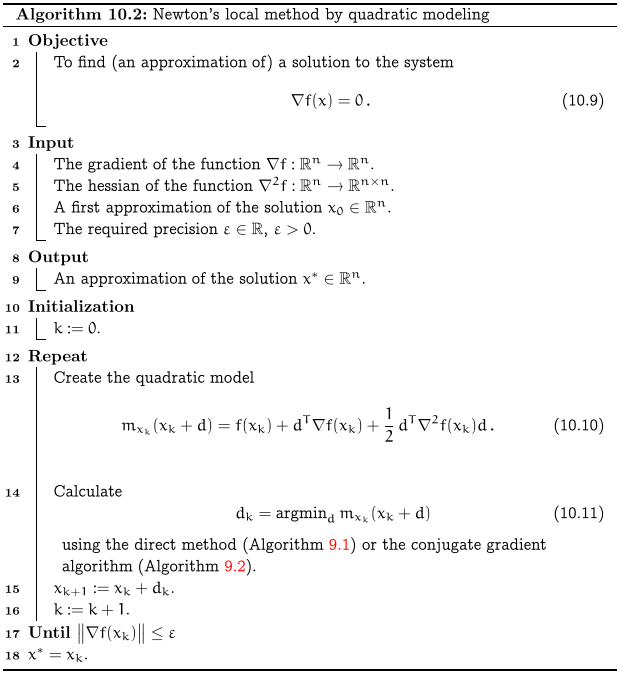

We test the algorithm on the Rosenbrock function. It is described in Section 11.6 of the book for two variables.  The implementation below involves $n$ variables: \\[f(x) = \sum_{i=1}^{n-1} f_i(x) = \sum_{i=1}^{n-1} 100 (x_{i+1}-x_i^2)^2 + (1-x_i)^2.\\]
The calculation of the derivatives is based on the partial derivatives of the functions $f_i$:
\\[
\begin{array}{rcl}
\partial f_i/\partial x_i&=& -400 x_i (x_{i+1}-x_i^2) - 2(1-x_i), \\\\
\partial f_i/\partial x_{i+1}&=& 200 (x_{i+1}-x_i^2), \\\\
\partial^2 f_i/\partial x^2_i  &=& -400 x_{i+1}+ 1200 x_i^2 + 2, \\\\
\partial^2 f_i/\partial x_i \partial x_{i+1}  &=& -400 x_i^2, \\\\
\partial^2 f_i/\partial x^2_{i+1}  &=& 200. 
\end{array}
\\]

Algoritmo 10.2 - Newton por modelagem quadrática
Ponto inicial: [-1.2, 1.0]
Iteração |      f(x)       |    ||grad||    |       passo
       0 |   2.420000e+01 |   2.328677e+02 |   3.814759e-01
       1 |   4.731884e+00 |   4.639426e+00 |   4.950945e+00
       2 |   1.411845e+03 |   1.370790e+03 |   3.757859e+00
       3 |   5.596552e-02 |   4.731104e-01 |   4.317761e-01
       4 |   3.131891e-01 |   2.502745e+01 |   5.596407e-02
       5 |   1.852740e-11 |   8.608633e-06 |   9.624778e-06
       6 |   3.432646e-20 |   8.285706e-09 |

Convergência atingida.
Resultado final
x* = [0.9999999999999999, 0.9999999999814724]
f(x*) = 3.4326461875363225e-20
grad f(x*) = [7.410960511933239e-9, -3.7054803669889225e-9]
||grad f(x*)|| = 8.285705791275366e-9

Classificação do ponto:
Autovalores da Hessiana:
[0.39936076896509576, 1001.6006392384456]
Conclusão: mínimo local.

Valor esperado teoricamente:
x* = [1, 1]
f(x*) = 0
Teste com vários pontos iniciais

Ponto inicial: [-1.2, 1.0]
Algoritmo 10.2 -

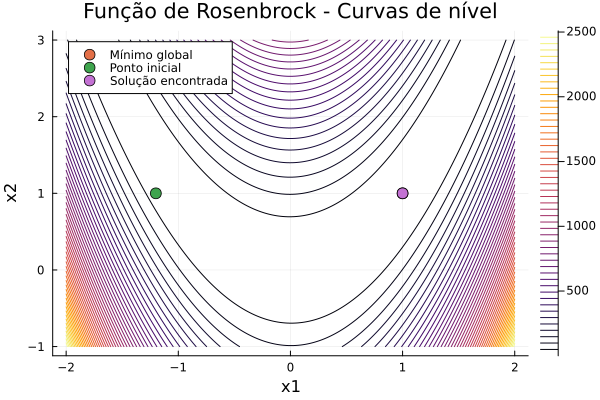

In [1]:
using LinearAlgebra
using Printf
using Plots

# Função de Rosenbrock em n variáveis
#
# f(x) = sum_{i=1}^{n-1} [100*(x[i+1] - x[i]^2)^2 + (1 - x[i])^2]


function rosenbrock(x)
    n = length(x)
    soma = 0.0

    for i in 1:n-1
        soma += 100.0 * (x[i+1] - x[i]^2)^2 + (1.0 - x[i])^2
    end

    return soma
end

# Gradiente da função de Rosenbrock

function grad_rosenbrock(x)
    n = length(x)
    g = zeros(n)

    # Primeiro termo
    g[1] = -400.0*x[1]*(x[2] - x[1]^2) - 2.0*(1.0 - x[1])

    # Termos intermediários
    for i in 2:n-1
        g[i] = 200.0*(x[i] - x[i-1]^2) -
               400.0*x[i]*(x[i+1] - x[i]^2) -
               2.0*(1.0 - x[i])
    end

    # Último termo
    g[n] = 200.0*(x[n] - x[n-1]^2)

    return g
end

# Hessiana da função de Rosenbrock

function hess_rosenbrock(x)
    n = length(x)
    H = zeros(n, n)

    # Primeiro elemento diagonal
    H[1,1] = 1200.0*x[1]^2 - 400.0*x[2] + 2.0
    H[1,2] = -400.0*x[1]
    H[2,1] = H[1,2]

    # Elementos intermediários
    for i in 2:n-1
        H[i,i] = 1200.0*x[i]^2 - 400.0*x[i+1] + 202.0

        H[i,i+1] = -400.0*x[i]
        H[i+1,i] = H[i,i+1]

        H[i,i-1] = -400.0*x[i-1]
        H[i-1,i] = H[i,i-1]
    end

    # Último elemento diagonal
    H[n,n] = 200.0

    return H
end


# Classificação do ponto encontrado


function classificar_ponto_rosenbrock(x)
    H = hess_rosenbrock(x)
    autovalores = eigvals(H)

    println("\nClassificação do ponto:")
    println("Autovalores da Hessiana:")
    println(autovalores)

    if all(autovalores .> 0)
        println("Conclusão: mínimo local.")
    elseif all(autovalores .< 0)
        println("Conclusão: máximo local.")
    elseif any(autovalores .> 0) && any(autovalores .< 0)
        println("Conclusão: ponto de sela.")
    else
        println("Conclusão: teste inconclusivo.")
    end
end

# Algoritmo 10.2
# Método de Newton local por modelagem quadrática
#
# Modelo:
# m_k(x_k+d) = f(x_k) + d'g + 1/2 d'Hd
#
# A minimização do modelo gera:
# H*d = -g


function newton_modelo_quadratico(x0; ε=1e-8, max_iter=100)
    x = copy(x0)


    println("Algoritmo 10.2 - Newton por modelagem quadrática")
    println("Ponto inicial: ", x0)

    println("Iteração |      f(x)       |    ||grad||    |       passo")
 

    for k in 0:max_iter
        fvalor = rosenbrock(x)
        g = grad_rosenbrock(x)
        H = hess_rosenbrock(x)

        norma_grad = norm(g)

        @printf("%8d | %14.6e | %14.6e |", k, fvalor, norma_grad)

        if norma_grad <= ε
            println("\n\nConvergência atingida.")
            return x
        end

        if abs(det(H)) < 1e-12
            error("Hessiana singular ou quase singular. O método não está definido.")
        end

        # Calcula d_k = argmin m_k(x_k+d)
        # Isto equivale a resolver H*d = -g
        d = H \ (-g)

        @printf(" %14.6e\n", norm(d))

        # Atualização
        x = x + d
    end

    println("\nNúmero máximo de iterações atingido.")
    return x
end

# Teste para n = 2
# Função de Rosenbrock clássica:
# f(x1,x2) = 100(x2 - x1^2)^2 + (1 - x1)^2
# Mínimo global esperado: x* = [1, 1]
# f(x*) = 0


x0 = [-1.2, 1.0]

x_sol = newton_modelo_quadratico(x0, ε=1e-8, max_iter=100)


println("Resultado final")

println("x* = ", x_sol)
println("f(x*) = ", rosenbrock(x_sol))
println("grad f(x*) = ", grad_rosenbrock(x_sol))
println("||grad f(x*)|| = ", norm(grad_rosenbrock(x_sol)))

classificar_ponto_rosenbrock(x_sol)

println("\nValor esperado teoricamente:")
println("x* = [1, 1]")
println("f(x*) = 0")

# ============================================================
# Teste com outros pontos iniciais
# ============================================================

pontos_iniciais = [
    [-1.2, 1.0],
    [-1.0, 1.0],
    [0.0, 0.0],
    [2.0, 2.0],
    [-2.0, 2.0]
]

println("Teste com vários pontos iniciais")


for x0_teste in pontos_iniciais
    try
        println("\nPonto inicial: ", x0_teste)

        x_resultado = newton_modelo_quadratico(x0_teste, ε=1e-8, max_iter=100)

        println("Solução encontrada: ", x_resultado)
        println("f(x*) = ", rosenbrock(x_resultado))
        println("||grad|| = ", norm(grad_rosenbrock(x_resultado)))

    catch e
        println("Erro no ponto inicial ", x0_teste, ": ", e)
    end
end

# ============================================================
# Gráfico de contorno para n = 2
# ============================================================

x1_vals = range(-2, 2, length=300)
x2_vals = range(-1, 3, length=300)

Z = [rosenbrock([x1, x2]) for x2 in x2_vals, x1 in x1_vals]

contour(
    x1_vals,
    x2_vals,
    Z,
    levels=50,
    xlabel="x1",
    ylabel="x2",
    title="Função de Rosenbrock - Curvas de nível",
    label=false
)

scatter!(
    [1.0],
    [1.0],
    label="Mínimo global",
    markersize=6
)

scatter!(
    [x0[1]],
    [x0[2]],
    label="Ponto inicial",
    markersize=6
)

scatter!(
    [x_sol[1]],
    [x_sol[2]],
    label="Solução encontrada",
    markersize=6
)

We now apply the algorithm on example 5.8. In this case, the algorithm fails to converge, and one hessian is not positive definite. We try first using the direct method to solve the quadratic problem. An error is triggered. 

In [8]:
using LinearAlgebra

function newton_modelo_quadratico_exemplo58(x0; ε=1e-8, max_iter=20)
    x = copy(x0)

    println("Algoritmo 10.2 aplicado ao Exemplo 5.8")
    println("Ponto inicial: ", x0)
    println("-----------------------------------------------------")
    println("Iteração | x1 | x2 | ||grad|| | det(H)")
    println("-----------------------------------------------------")

    for k in 0:max_iter
        g = grad_f(x)
        H = hess_f(x)
        norma_g = norm(g)
        autovalores = eigvals(H)

        println(k, " | ", x[1], " | ", x[2], " | ", norma_g, " | ", det(H))

        if norma_g <= ε
            println("\nConvergência atingida.")
            return x
        end

        if !all(autovalores .> 0)
            error("A Hessiana não é positiva definida. O modelo quadrático não possui mínimo.")
        end

        d = H \ (-g)

        x = x + d
    end

    return x
end

x0 = [1.0, 1.0]

x_sol = newton_modelo_quadratico_exemplo58(x0)

Algoritmo 10.2 aplicado ao Exemplo 5.8
Ponto inicial: [1.0, 1.0]
-----------------------------------------------------
Iteração | x1 | x2 | ||grad|| | det(H)
-----------------------------------------------------
0 | 1.0 | 1.0 | 1.7551651237807455 | -1.2483757241417108


LoadError: A Hessiana não é positiva definida. O modelo quadrático não possui mínimo.

  Julia 1.12 has introduced more strict world age semantics for global bindings.
  !!! This code may malfunction under Revise.
  !!! This code will error in future versions of Julia.
Hint: Add an appropriate `invokelatest` around the access to this binding.
To make this warning an error, and hence obtain a stack trace, use `julia --depwarn=error`.


If we try with the conjugate gradient method, an error is also triggered. 